# Save outputs to drive
Don't run this cell initially. Instead, after you've completed an experiment and obtained a result you can run it to save that result to a unique folder in drive (so that it doesn't overwrite old saved data)

In [ ]:
drive.mount('/content/drive')

current_time = datetime.now()
print(current_time)

outputs_foldername = f"BlorbMyGlorb {current_time}"
# !cp -r model_outputs /content/drive/MyDrive/outputs_foldername  - Doesn't work, treats outputs_foldername as string; leaving here for posterity

shutil.copytree("model_outputs",f"/content/drive/MyDrive/{outputs_foldername}") # Correct way to do it

with open(f"/content/drive/MyDrive/{outputs_foldername}/output_info.txt","w") as info_file:
  info_file.write(f"Prompt: {PROMPT_TEMPLATE}\n")
  info_file.write(f"Dataset Name: {DATASET_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2026-03-13 01:42:12.102533


In [ ]:
!pip install -q torch transformers accelerate pandas pyarrow scikit-learn matplotlib huggingface_hub bitsandbytes

In [ ]:
from __future__ import annotations
import json
from pathlib import Path

# Numpy and Pandas double wammy
import numpy as np
import pandas as pd

# Machine learning util
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# Used to gain access to linux shell commands (e.g. !cp)
import shutil

# Misc util
from google.colab import drive
from datetime import datetime

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
from google.colab import files
print("Upload your CSV file (e.g. cities.csv):")
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f"Uploaded: {csv_name}")

df_raw = pd.read_csv(csv_name)
print(f"Raw columns: {list(df_raw.columns)}")
print(f"Raw shape: {df_raw.shape}")
print(df_raw.head())

raw_labels = df_raw["label"]
if np.issubdtype(raw_labels.dtype, np.integer):
    pass
elif raw_labels.dtype == bool:
    df_raw["label"] = raw_labels.astype(int)
else:
    label_map = {"true": 1, "false": 0, "True": 1, "False": 0, True: 1, False: 0}
    df_raw["label"] = raw_labels.map(label_map)
    unmapped = df_raw["label"].isna().sum()
    if unmapped > 0:
        print(f"WARNING: {unmapped} rows had unrecognized labels, dropping them")
        df_raw = df_raw.dropna(subset=["label"])
    df_raw["label"] = df_raw["label"].astype(int)

domain_name = csv_name.replace(".csv", "")
df_raw["id"] = [f"{domain_name}_{i:06d}" for i in range(len(df_raw))]
df_raw["domain"] = domain_name

DATASET_PATH = csv_name.replace(".csv", ".parquet")
df_raw.to_parquet(DATASET_PATH, index=False)
print(f"\nConverted to {DATASET_PATH}")
print(f"  {len(df_raw)} rows, label distribution: {df_raw['label'].value_counts().to_dict()}")

Upload your CSV file (e.g. cities.csv):


Saving cities.csv to cities (2).csv
Uploaded: cities (2).csv
Raw columns: ['statement', 'label', 'city', 'country', 'correct_country']
Raw shape: (1496, 5)
                                        statement  label       city  \
0             The city of Krasnodar is in Russia.      1  Krasnodar   
1       The city of Krasnodar is in South Africa.      0  Krasnodar   
2                  The city of Lodz is in Poland.      1       Lodz   
3  The city of Lodz is in the Dominican Republic.      0       Lodz   
4            The city of Maracay is in Venezuela.      1    Maracay   

                  country correct_country  
0                  Russia          Russia  
1            South Africa          Russia  
2                  Poland          Poland  
3  the Dominican Republic          Poland  
4               Venezuela       Venezuela  

Converted to cities (2).parquet
  1496 rows, label distribution: {1: 748, 0: 748}


In [ ]:
# ---- CONFIG ----
MODEL_NAME = "meta-llama/Llama-2-13b-hf"   # change to any HF model
FEATURES_DIR = "features"
BATCH_SIZE = 4
MAX_LENGTH = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROMPT_TEMPLATE = "Answer True/False: {statement}"
PROBE_C = 1.0
TEST_SIZE = 0.2
SEED = 42
N_PAIRS = 10000
COV_REG = 1e-4
USE_4BIT = False  # 4-bit quantization — required for 13B models on T4 (16 GB VRAM)

print(f"Model: {MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"4-bit quantization: {USE_4BIT}")
print(f"Batch size: {BATCH_SIZE}")

Model: meta-llama/Llama-2-13b-hf
Device: cuda
4-bit quantization: False
Batch size: 4


In [ ]:
from huggingface_hub import login
login()  # paste your HuggingFace token when prompted

# Utility Functions

In [ ]:
def _infer_input_device(model, fallback_device: str) -> torch.device:
    """ Just sets up CUDA shenanigans """
    if hasattr(model, "hf_device_map") and isinstance(model.hf_device_map, dict):
        for key in ["model.embed_tokens", "embed_tokens", "lm_head"]:
            if key in model.hf_device_map:
                dev = model.hf_device_map[key]
                if isinstance(dev, int):
                    return torch.device(f"cuda:{dev}")
                return torch.device(str(dev))
        first_dev = next(iter(model.hf_device_map.values()), None)
        if first_dev is not None:
            if isinstance(first_dev, int):
                return torch.device(f"cuda:{first_dev}")
            return torch.device(str(first_dev))
    return torch.device(fallback_device)

def model_output(model_name, dataset_path, out_dir, batch_size, max_length, device,
                 prompt_template, use_4bit=False):
    """Generate the model's next-token for each prompt and classify as true/false.

    Saved to CSV: prompt_num, answer, output, hallucination
    Output: #, string ("true"/"false"), string ("true/false"), "yes/no"
    """

    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    df = pd.read_parquet(dataset_path)
    required = {"id", "domain", "label", "statement"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {', '.join(sorted(missing))}")

    texts = [prompt_template.format(statement=str(s)) for s in df["statement"].tolist()]
    ground_truth = df["label"].astype(int).to_numpy()
    print(f"Loaded {len(texts)} prompts")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    dtype = torch.float16 if device.startswith("cuda") else torch.float32

    if use_4bit and device.startswith("cuda"):
        print("Loading model with 4-bit quantization (NF4)...")
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto",
        )
    elif device.startswith("cuda"):
        print(f"Loading model in {dtype}...")
        model = AutoModelForCausalLM.from_pretrained(
            model_name, dtype=dtype, device_map="auto",
        )
    else:
        print(f"Loading model in {dtype}...")
        model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype)
        model.to(device)
    model.eval()
    input_device = _infer_input_device(model, fallback_device=device)
    print(f"Model loaded. Input device: {input_device}")

    results = []
    total_batches = (len(texts) + batch_size - 1) // batch_size

    all_batch_activations = []

    for batch_num, i in enumerate(range(0, len(texts), batch_size)):
        if batch_num % 20 == 0:
            print(f"  Batch {batch_num + 1}/{total_batches}")
        batch_texts = texts[i : i + batch_size]

        enc = tokenizer(
            batch_texts, return_tensors="pt", padding=True,
            truncation=True, max_length=max_length,
        )
        enc = {k: v.to(input_device) for k, v in enc.items()}

        with torch.no_grad():
            generated_ids = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                output_hidden_states=True,
                return_dict_in_generate=True,
            )

        new_token_ids = generated_ids.sequences[:, enc["input_ids"].shape[1]:]
        decoded_tokens = tokenizer.batch_decode(new_token_ids, skip_special_tokens=True)
        hs = generated_ids.hidden_states

        # Grab the middle layers
        target_layers = torch.stack([h[:, -1, :] for h in hs[0][12:17]]).cpu().numpy()
        all_batch_activations.append(target_layers)


        for j, raw_output in enumerate(decoded_tokens):
            idx = i + j
            output_stripped = raw_output.strip()
            output_lower = output_stripped.lower()

            if output_lower == "true":
                model_answer = 1
            elif output_lower == "false":
                model_answer = 0
            else:
                model_answer = -1

            gt = int(ground_truth[idx])
            gt_str = "True" if gt == 1 else "False"

            if model_answer == -1:
                hallucinated = "N/A"
            else:
                hallucinated = "Yes" if model_answer != gt else "No"

            results.append({
                "prompt_num": idx,
                "answer": gt_str,
                "output": output_stripped,
                "hallucination": hallucinated,
            })

    # Save the target intermediate layer activations to an npz file for later analysis
    all_batch_activations = np.concatenate(all_batch_activations, axis=1)
    np.savez_compressed(
        out_path / "hs_12_to_17.npz",
        activations=all_batch_activations
    )

    # Big D's Code code
    results_df = pd.DataFrame(results)
    csv_path = out_path / "model_outputs.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"\nSaved {len(results_df)} results to {csv_path}")

    valid = results_df[results_df["hallucination"] != "N/A"]
    if len(valid) > 0:
        n_hall = (valid["hallucination"] == "Yes").sum()
        print(f"Hallucination rate: {n_hall}/{len(valid)} ({100 * n_hall / len(valid):.1f}%)")
    n_na = (results_df["hallucination"] == "N/A").sum()
    if n_na > 0:
        print(f"Unrecognized outputs (not true/false): {n_na}")
        print("Sample unrecognized:", results_df[results_df["hallucination"] == "N/A"]["output"].value_counts().head(10).to_dict())

    return results_df



OUTPUT_DIR = "model_outputs"
PROMPT_TEMPLATE_TF = "True or False: {statement}\nAnswer:"

output_df = model_output(
    model_name=MODEL_NAME,
    dataset_path=DATASET_PATH,
    out_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    device=DEVICE,
    prompt_template=PROMPT_TEMPLATE_TF,
    use_4bit=USE_4BIT,
)

print("\n--- First 20 rows ---")
print(output_df.head(20).to_string(index=False))
print(f"\n--- Output value counts ---")
print(output_df["output"].value_counts().head(15))
print(f"\n--- Hallucination breakdown ---")
print(output_df["hallucination"].value_counts())

from google.colab import files
files.download(f"{OUTPUT_DIR}/model_outputs.csv")


Loaded 1496 prompts
Loading model in torch.float16...


Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

Model loaded. Input device: cuda:0
  Batch 1/374
  Batch 21/374
  Batch 41/374
  Batch 61/374
  Batch 81/374
  Batch 101/374
  Batch 121/374


(5, 1200, 5120)


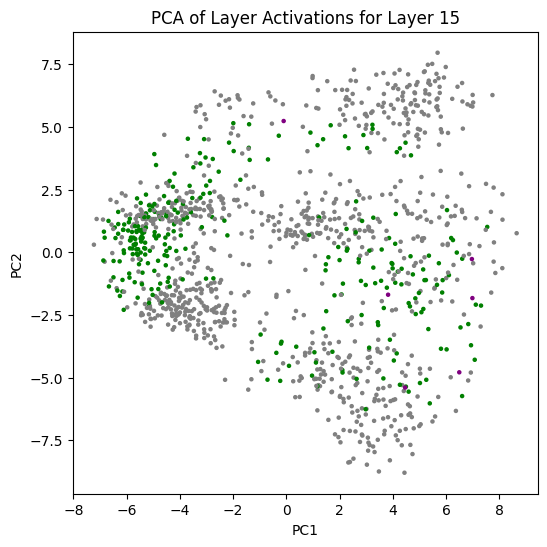

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

data = np.load("model_outputs/hs_12_to_17.npz")
acts = data["activations"]

print(acts.shape)

layer = 3
# Layer = layer + 12 (since we only grabbed 12:17)
X = acts[layer]  # shape (N, hidden_dim)

import matplotlib.pyplot as plt


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Extract hallucination status
model_outputs = pd.read_csv("model_outputs/model_outputs.csv")
hallucinated = model_outputs[model_outputs["hallucination"] == "Yes"]
non_hallucinated = model_outputs[model_outputs["hallucination"] == "No"]

hal_indices = hallucinated["prompt_num"].to_numpy()
non_hal_indices = non_hallucinated["prompt_num"].to_numpy()
colors = []
for _, row in model_outputs.iterrows():
    if row["hallucination"] == "Yes" and row["output"] == "True":
        colors.append("green")
    elif row["hallucination"] == "Yes" and row["output"] == "False":
        colors.append("purple")
    # elif row["output"] == "True":
    #     colors.append("red")
    # elif row["output"] == "False":
    #     colors.append("blue")
    else:
        colors.append("gray")

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5,c=colors)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA of Layer Activations for Layer {12 + layer}")
# plt.savefig("PCA_layer_activations.png")
plt.show()

Activations PCA Shape: (1496, 2)


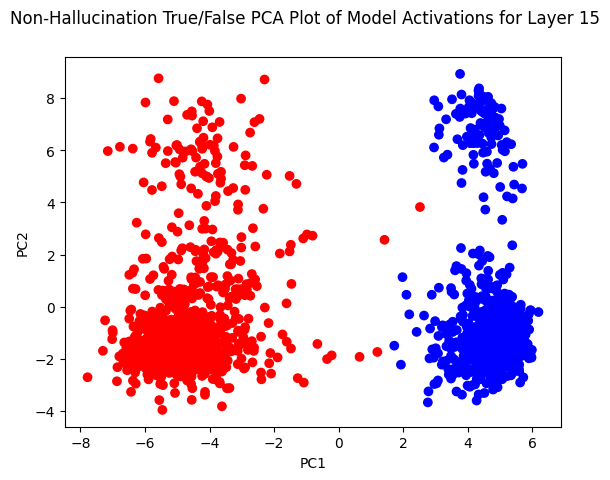

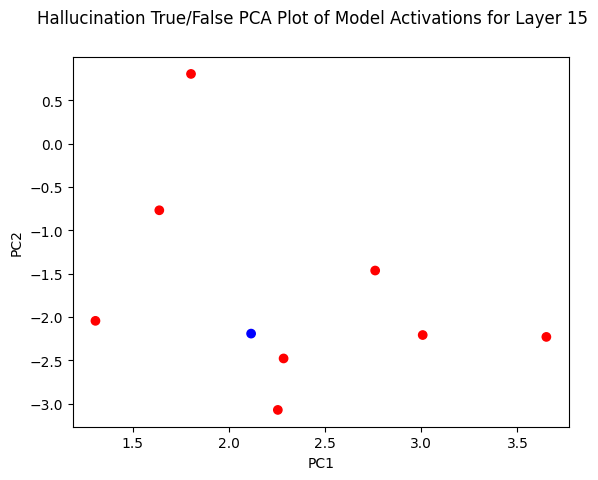

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
from enum import Enum # We will use this for convenience and readability

class answer_status(Enum):
  TRUE_POSITIVE = 0
  TRUE_NEGATIVE = 1
  FALSE_POSITIVE = 2
  FALSE_NEGATIVE = 3
  NOT_AVAILABLE = 4


# Load the model activations data
data = np.load("model_outputs/hs_12_to_17.npz")
acts = data["activations"]


layer = 3
# Layer = layer + 12 (since we only grabbed 12:17)
X = acts[layer]  # shape (N, hidden_dim)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) # shape (N, 2)
print(f"Activations PCA Shape: {X_pca.shape}")

model_outputs = pd.read_csv("model_outputs/model_outputs.csv")

# This will examplewise hold whether the model returned a true positive, false positive, etc
answer_statuses = []

for _,row in model_outputs.iterrows():
  hallucinated = row["hallucination"]
  answer = row["output"]

  # True/false positives
  if hallucinated == "No" and answer == "True":
    answer_statuses.append(answer_status.TRUE_POSITIVE)
  elif hallucinated == "Yes" and answer == "True":
    answer_statuses.append(answer_status.FALSE_POSITIVE)

  # True/false negatives
  elif hallucinated == "No" and answer == "False":
    answer_statuses.append(answer_status.TRUE_NEGATIVE)
  elif hallucinated == "Yes" and answer == "False":
    answer_statuses.append(answer_status.FALSE_NEGATIVE)

  # N/A
  else:
    answer_statuses.append(answer_status.NOT_AVAILABLE)

# Not my proudest work
answer_statuses = [status.value for status in answer_statuses]
answer_statuses = np.array(answer_statuses)

# These are masks to extract non-hallucinations, hallucinations, and indecisive answers respectively
true_mask = np.where( (answer_statuses == 0) | (answer_statuses == 1), True, False)
false_mask = np.where( (answer_statuses == 2) | (answer_statuses == 3), True, False)
na_mask = np.where(answer_statuses == 4, True, False)

# Here we will plot the true positive/negative answers to demonstrate linear structure
truthfig,truthax = plt.subplots()
truthfig.suptitle(f"Non-Hallucination True/False PCA Plot of Model Activations for Layer {layer + 12}")
truthax.set_xlabel("PC1")
truthax.set_ylabel("PC2")

truthful = X_pca[true_mask]
truthful_answer_statuses = answer_statuses[true_mask]

# True positive - blue
# True negative - red
truthful_colors = ["blue" if status == answer_status.TRUE_POSITIVE.value else "red" for status in truthful_answer_statuses]
truthax.scatter(truthful[:,0],truthful[:,1],c=truthful_colors)

# Here we will plot the false positive/negatives answers to show the pattern
hallucinationfig,hallucinationax = plt.subplots()
hallucinationfig.suptitle(f"Hallucination True/False PCA Plot of Model Activations for Layer {layer + 12}")
hallucinationax.set_xlabel("PC1")
hallucinationax.set_ylabel("PC2")

hallucinated = X_pca[false_mask]
hallucinated_answer_statuses = answer_statuses[false_mask]

# False positive - blue
# False negative - red
hallucinated_colors = ["blue" if status == answer_status.FALSE_POSITIVE.value else "red" for status in hallucinated_answer_statuses]
hallucinationax.scatter(hallucinated[:,0],hallucinated[:,1],c=hallucinated_colors)


# Here we will plot N/A to check validity of original prompting strategy (if there are too many, we need to reprompt)

truthfig.savefig("model_outputs/nonhal.png")
hallucinationfig.savefig("model_outputs/hal.png")


# K-Means Clustering

While the PCA Plot of non-hallucinated answers shows clear linear separabbility, the PCA plot of the hallucinated answers are inconclusive. Thus in the absence of a good guess at the form of the structure, we run K-means

In [ ]:
from sklearn.cluster import KMeans

model_outputs = pd.read_csv("model_outputs/model_outputs.csv")
hal_mask = (model_outputs["hallucination"] == "Yes").to_numpy()

data = np.load("model_outputs/hs_12_to_17.npz")
acts = data["activations"]
layer = 3
X = acts[layer]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

hal_X_pca = X_pca[hal_mask]
hal_outputs = model_outputs[hal_mask]["output"].to_numpy()
hal_said_true = (hal_outputs == "True")

cluster_colors_map = {
    2: ["red", "blue"],
    3: ["red", "blue", "green"],
    4: ["red", "blue", "green", "orange"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

markers = np.where(hal_said_true, "^", "v")

for ax, k in zip(axes, [2, 3, 4]):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(hal_X_pca)

    cmap = cluster_colors_map[k]

    for c in range(k):
        mask_c = cluster_labels == c
        true_in_c = mask_c & hal_said_true
        false_in_c = mask_c & ~hal_said_true

        ax.scatter(hal_X_pca[true_in_c, 0], hal_X_pca[true_in_c, 1],
                   c=cmap[c], marker="^", s=15, label=f"C{c} said True" if c == 0 or True else "")
        ax.scatter(hal_X_pca[false_in_c, 0], hal_X_pca[false_in_c, 1],
                   c=cmap[c], marker="v", s=15, label=f"C{c} said False" if c == 0 or True else "")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{k}-Means on Hallucinations (Layer {layer + 12})")
    ax.legend(fontsize=6, markerscale=1.5)

plt.tight_layout()
plt.savefig("model_outputs/kmeans_hallucinations.png", dpi=150)
plt.show()

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(hal_X_pca)
    print(f"\n{k}-Means:")
    for c in range(k):
        in_cluster = cluster_labels == c
        n_said_true = (in_cluster & hal_said_true).sum()
        n_said_false = (in_cluster & ~hal_said_true).sum()
        print(f"  Cluster {c}: {in_cluster.sum()} points — said True: {n_said_true}, said False: {n_said_false}")